In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Code Berikut menunjukkan penggunaan dari library OpenCV cv.Threshold

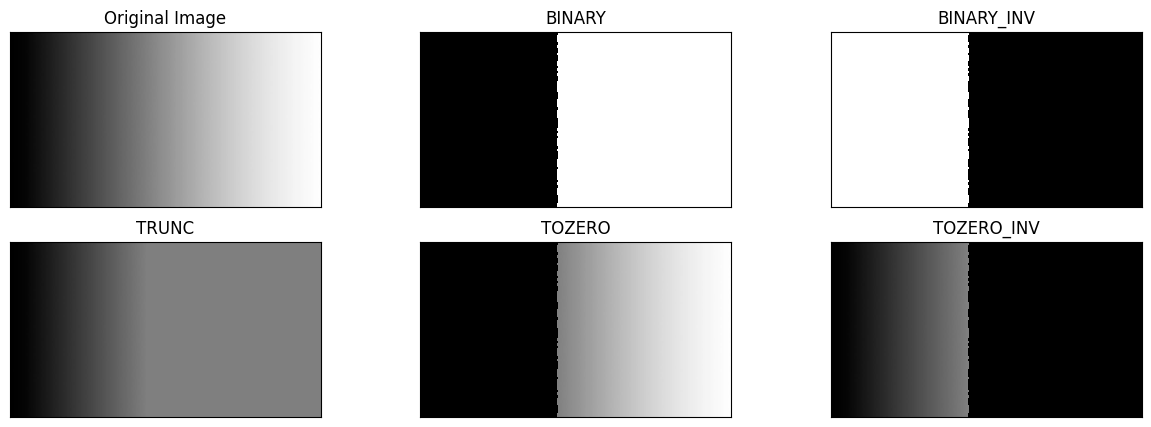

In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

filename = ('/content/drive/MyDrive/PCVK/Images/gradient.jpg')
img = cv.imread(filename)
thresh = 127      #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

## Berikut adalah contoh code untuk Adaptive Threshold

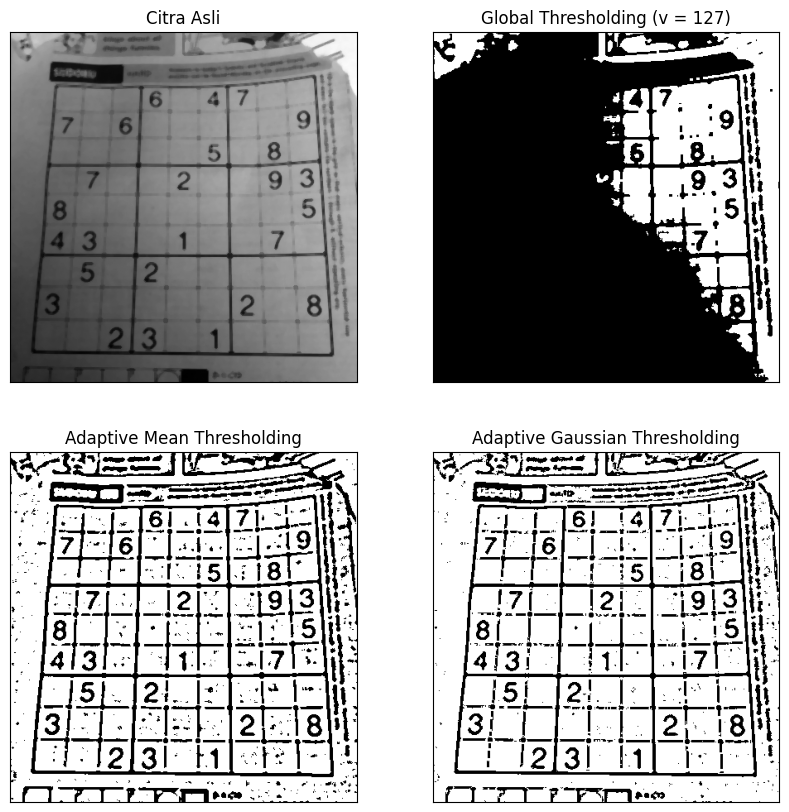

In [5]:
filename = ('/content/drive/MyDrive/PCVK/Images/sudoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)

thresh = 127

ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, cv
 .THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C
 , cv.THRESH_BINARY,11,2)

titles = ['Citra Asli', 'Global Thresholding (v = 127)',
            'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]

plt.figure(figsize = (10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

## Berikut adalah code contoh penggunaan Otsu’s dengan library OpenCV

/tmp/ipython-input-3817661696.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


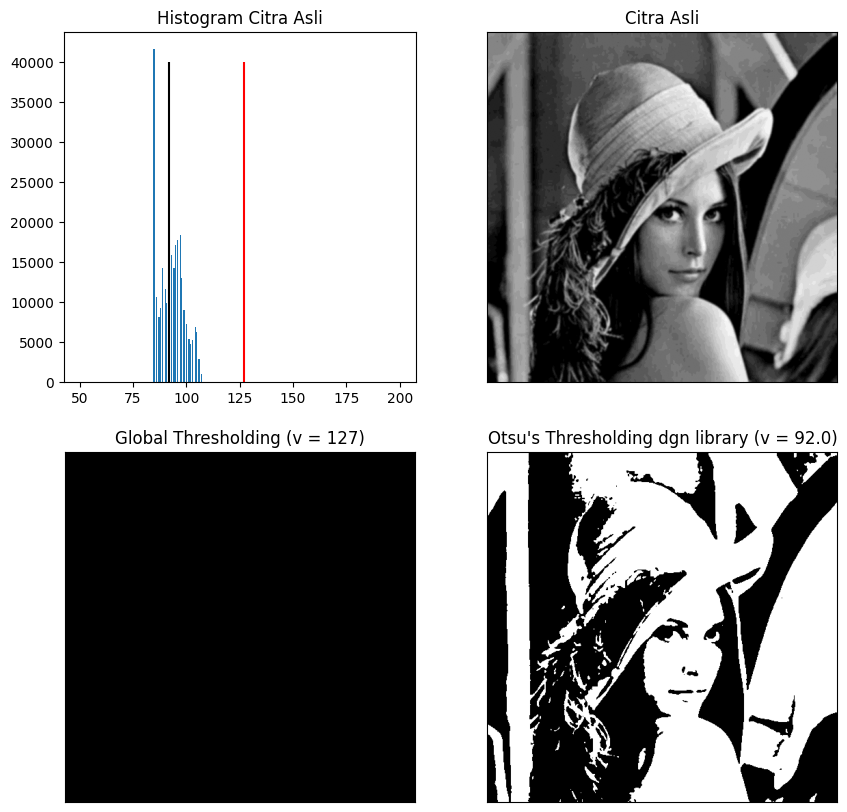

In [7]:
# Dengan Library
filename = ('/content/drive/MyDrive/PCVK/Images/lena_gs_lc2.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127

ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red')     #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black')  #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
    plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


## Code berikut akan menampilkan hasil dari threshold Otsu’s tanpa Gaussian Filter dan dengan menggunakan Gaussian Filter

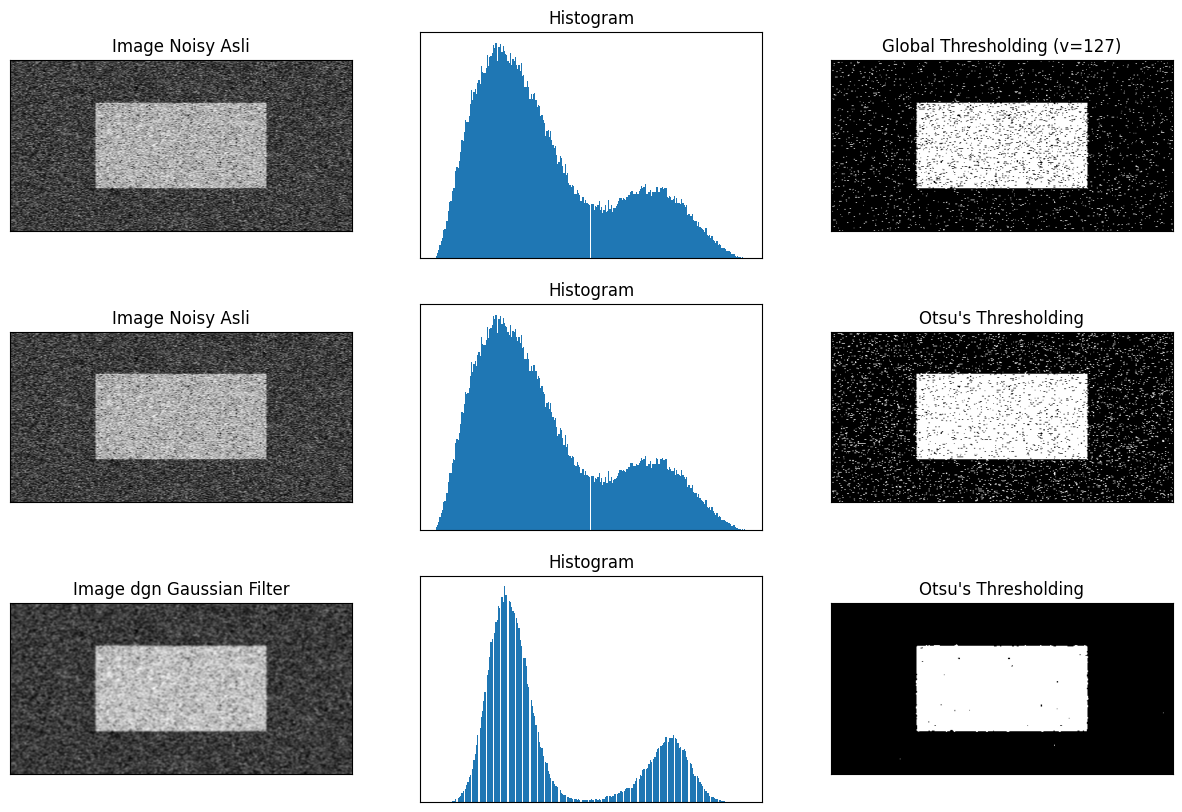

In [8]:
filename = ('/content/drive/MyDrive/PCVK/Images/noisy2.png')
img = cv.imread(filename,0)

#Global Thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding setelah dilakukan Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
#plotting semua image
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Image Noisy Asli','Histogram','Global Thresholding (v=127)',
          'Image Noisy Asli','Histogram',"Otsu's Thresholding",
          'Image dgn Gaussian Filter','Histogram',"Otsu's Thresholding"]
plt.figure(figsize = (15,10))
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

## Berikut adalah code untuk penggunaan K-Means pada segmentasi citra

(<Axes: >, <matplotlib.image.AxesImage at 0x7cd570090f80>)

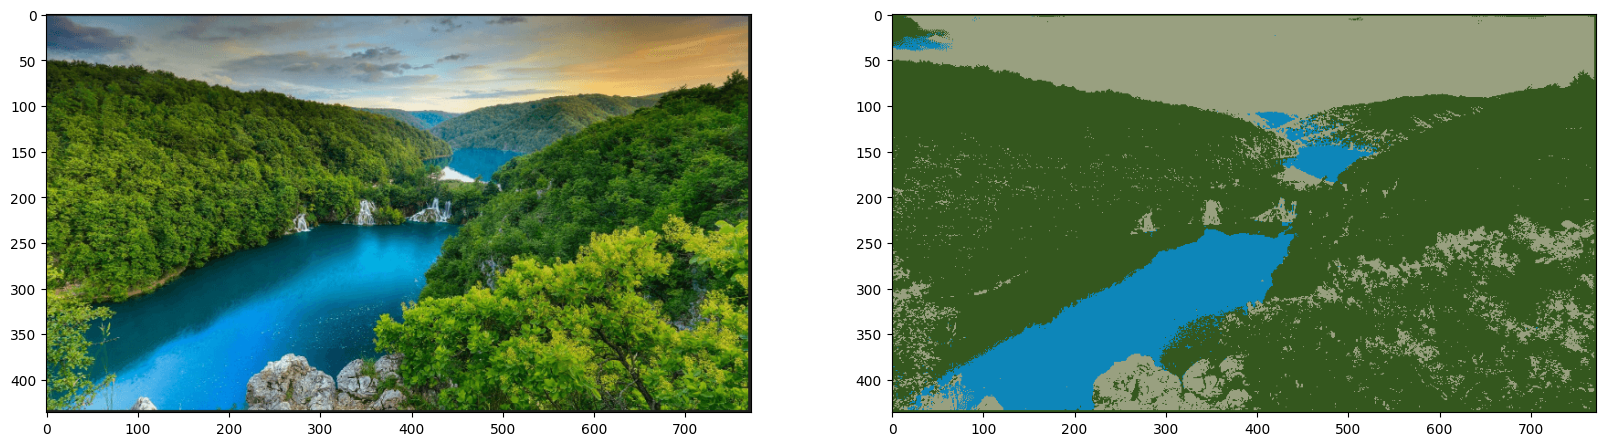

In [10]:
#KMeans Image Segmentation
filename = ('/content/drive/MyDrive/PCVK/Images/jungle.png')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
 kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)
'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di iterasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
 putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(segmented_image)

## Code berikut merupakan lanjutan dari code diatas yang digunakan untuk mengubah warna pada cluster tertentu

(<Axes: >, <matplotlib.image.AxesImage at 0x7cd573328f50>)

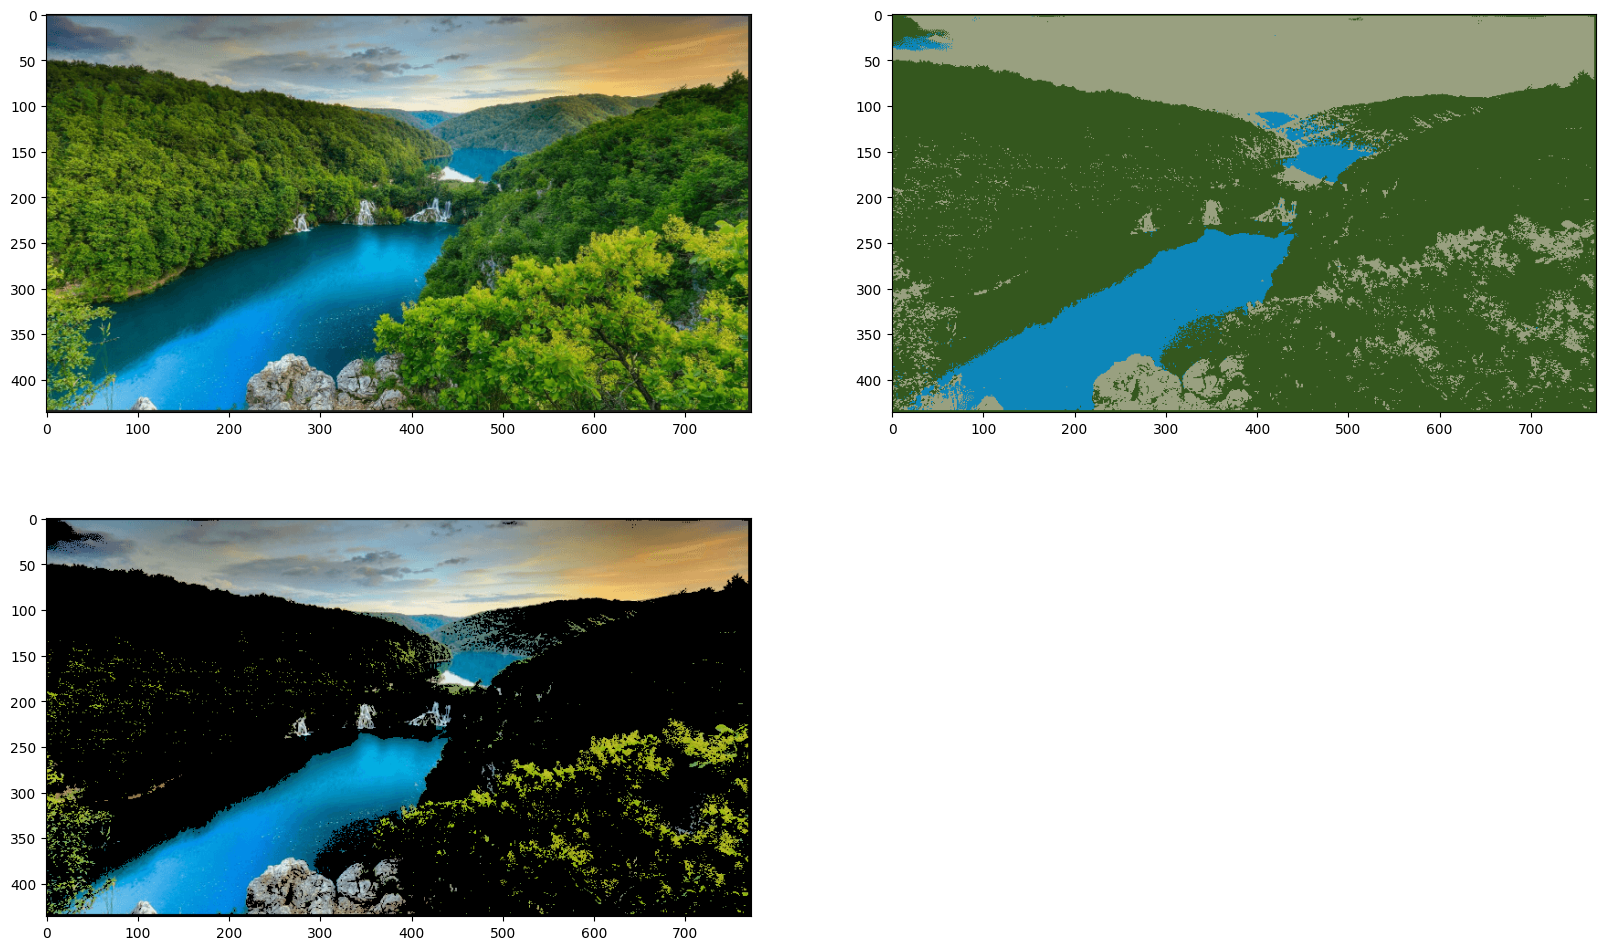

In [11]:
# ubah pixel di cluster 2 menjadi hitam
masked_image = np.copy(img)
# konvert ke bentuk vektor
masked_image = masked_image.reshape((-1, 3))
# cluster yang diubah
cluster = 2
masked_image[labels == cluster] = [0, 0, 0]
# konvert ke bentuk asli
masked_image = masked_image.reshape(img.shape)

plt.figure(figsize = (20,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(segmented_image)
plt.subplot(2,2,3),plt.imshow(masked_image)

# Tugas

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan threshold= 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di atas.

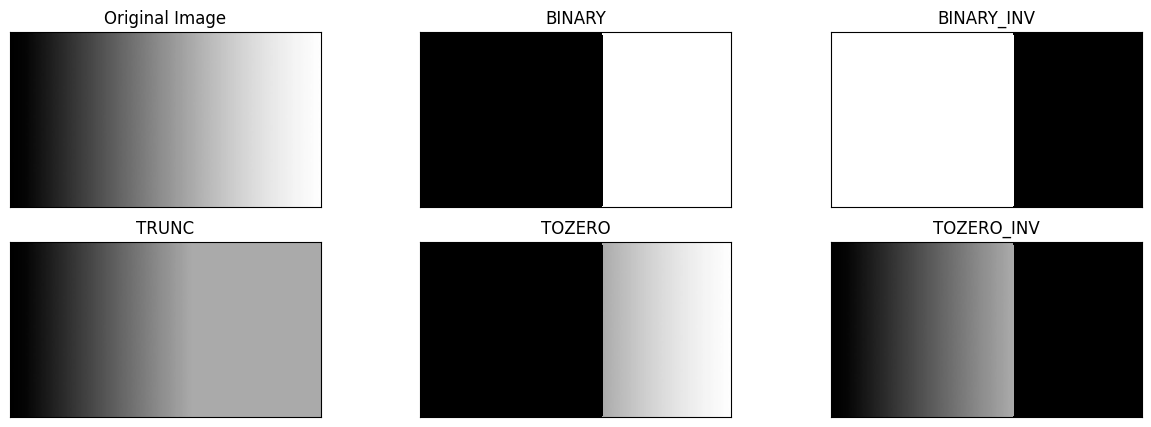

In [13]:
filename = ('/content/drive/MyDrive/PCVK/Images/gradient.jpg')
img = cv.imread(filename)
thresh = 170      #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

## Buat Otsu Thresholding tanpa menggunakan Library. Tampilkan juga nilai threshold saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

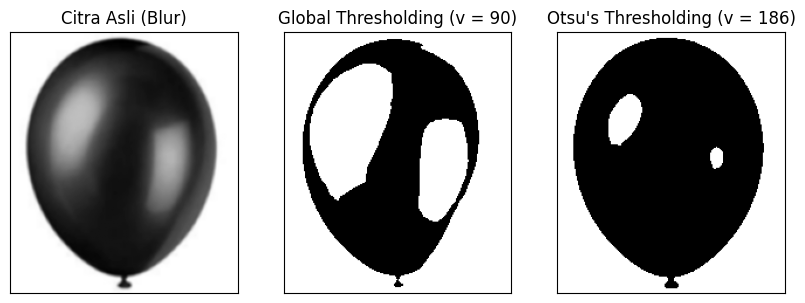

Global thresholding v = 90
Otsu's thresholding v = 186


In [18]:
filename = '/content/drive/MyDrive/PCVK/Images/balloon.jpg'
img = cv.imread(filename, 0)

# Gaussian blur
blur = cv.GaussianBlur(img, (5,5), 0)

# Global thresholding (v = 90)
ret, th1 = cv.threshold(blur, 90, 255, cv.THRESH_BINARY)

# "Otsu" versi manual pakai threshold 186
ret2, th2 = cv.threshold(blur, 186, 255, cv.THRESH_BINARY)

# Judul untuk gambar
titles = ['Citra Asli (Blur)', 'Global Thresholding (v = 90)', "Otsu's Thresholding (v = 186)"]
citra3 = [blur, th1, th2]

# Tampilkan hasil citra
plt.figure(figsize = (10,5))
for i in range(len(citra3)):
    plt.subplot(1,3,i+1), plt.imshow(citra3[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

print("Global thresholding v = 90")
print("Otsu's thresholding v = 186")

## Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.

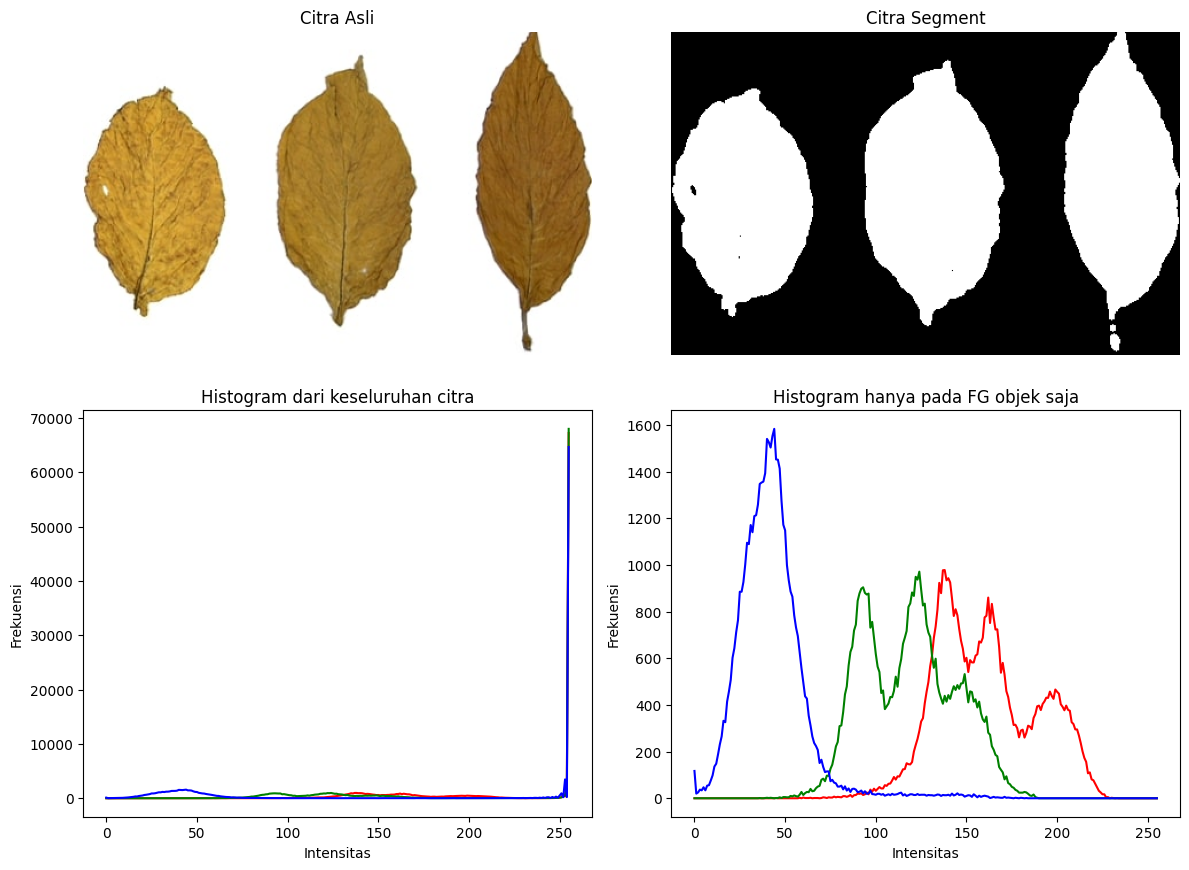

In [21]:
path = "/content/drive/MyDrive/PCVK/Images/tobacco.jpg"
img_bgr = cv.imread(path)
assert img_bgr is not None, "Gagal baca gambar. Cek path-nya."
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Segmentasi (buat mask FG putih, BG hitam)
gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
# Latar belakang putih → pakai OTSU + invert
_, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
# Bersihkan noise kecil
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)

# Histogram keseluruhan citra (RGB, tanpa mask)
hist_full_R = cv.calcHist([img_rgb], [0], None, [256], [0,256])  # R
hist_full_G = cv.calcHist([img_rgb], [1], None, [256], [0,256])  # G
hist_full_B = cv.calcHist([img_rgb], [2], None, [256], [0,256])  # B

# Histogram foreground saja (pakai mask)
hist_fg_R = cv.calcHist([img_rgb], [0], mask, [256], [0,256])
hist_fg_G = cv.calcHist([img_rgb], [1], mask, [256], [0,256])
hist_fg_B = cv.calcHist([img_rgb], [2], mask, [256], [0,256])

# Tampilkan seperti contoh (grid 2x2)
plt.figure(figsize=(12,9))

# (a) Citra Asli
plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis("off")

# (b) Citra Segment (mask)
plt.subplot(2,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Citra Segment")
plt.axis("off")

# (c) Histogram keseluruhan citra
plt.subplot(2,2,3)
plt.plot(hist_full_R, color='red')
plt.plot(hist_full_G, color='green')
plt.plot(hist_full_B, color='blue')
plt.title("Histogram dari keseluruhan citra")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")

# (d) Histogram foreground saja
plt.subplot(2,2,4)
plt.plot(hist_fg_R, color='red')
plt.plot(hist_fg_G, color='green')
plt.plot(hist_fg_B, color='blue')
plt.title("Histogram hanya pada FG objek saja")
plt.xlabel("Intensitas")
plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()

## Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang kuning saja. (Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya warna tertentu saja)

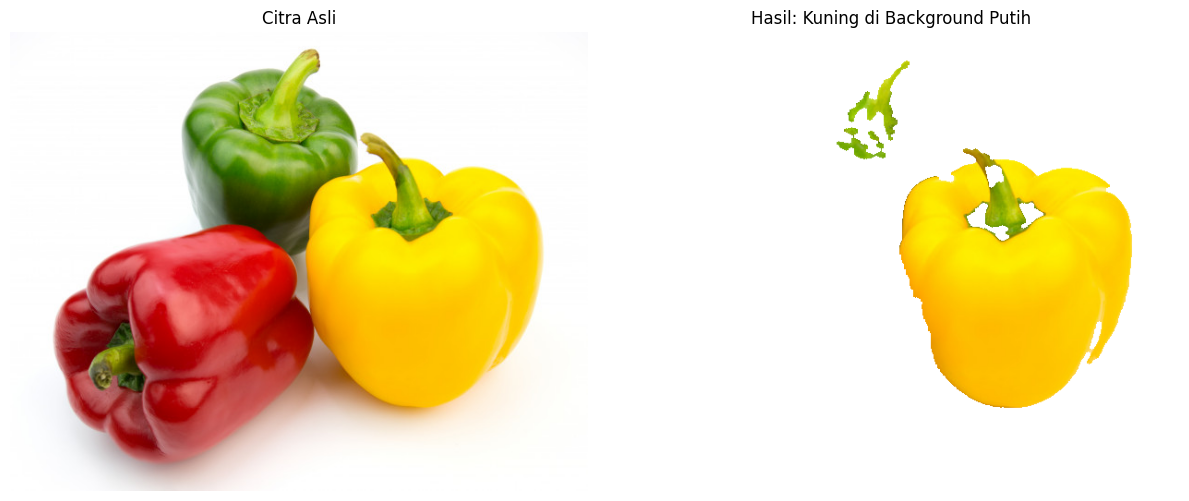

In [32]:
path = "/content/drive/MyDrive/PCVK/Images/peppers.jpg"
img_bgr = cv.imread(path)
assert img_bgr is not None, "Gagal baca gambar."
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)

# K-Means pada HSV
pixels = img_hsv.reshape(-1,3).astype(np.float32)
K = 6
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 50, 1.0)
_, labels, centers = cv.kmeans(pixels, K, None, criteria, 10, cv.KMEANS_PP_CENTERS)
labels = labels.ravel()
centers = centers.astype(np.float32)

# Pilih klaster kuning (rentang hue kuning)
yellow_idx = []
for i,(h,s,v) in enumerate(centers):
    if 20 <= h <= 40 and s >= 60 and v >= 60:   # inti kuning
        yellow_idx.append(i)
if not yellow_idx:  # fallback lebih longgar
    for i,(h,s,v) in enumerate(centers):
        if 18 <= h <= 45 and s >= 40 and v >= 50:
            yellow_idx.append(i)

mask_kmeans = np.isin(labels, yellow_idx).astype(np.uint8).reshape(img_hsv.shape[:2]) * 255

h,s,v = cv.split(img_hsv)
mask_hsv = cv.inRange(img_hsv,
                      np.array([20,  80, 140]),   # batas bawah (H,S,V)
                      np.array([40, 255, 255]))   # batas atas
mask = cv.bitwise_and(mask_kmeans, mask_hsv)

# Bersihkan noise kecil + haluskan tepi
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=1)

# buang komponen kecil (area filter)
num_labels, cc, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)
min_area = 500
for i in range(1, num_labels):
    if stats[i, cv.CC_STAT_AREA] < min_area:
        mask[cc == i] = 0

# Komposit ke background putih (bukan hitam)
result_rgb = np.full_like(img_rgb, 255)
result_rgb[mask==255] = img_rgb[mask==255]

# Tampilkan
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img_rgb);   plt.title("Citra Asli"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(result_rgb); plt.title("Hasil: Kuning di Background Putih"); plt.axis("off")
plt.tight_layout(); plt.show()


## Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda. Copas code dan hasil image di modul ini.

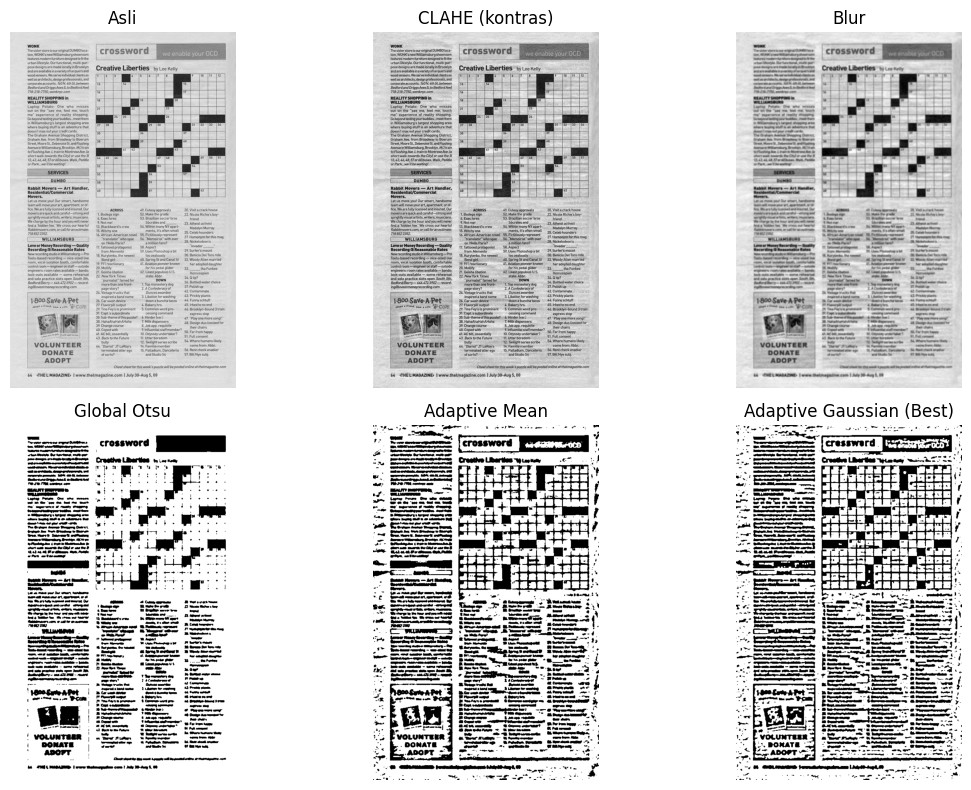

In [37]:
path = "/content/drive/MyDrive/PCVK/Images/crossword.jpg"
img = cv.imread(path, cv.IMREAD_GRAYSCALE)
assert img is not None, "Gagal membaca gambar. Cek path-nya."

# Praproses: tingkatkan kontras + kurangi noise
# CLAHE untuk meratakan pencahayaan
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_eq = clahe.apply(img)

# Denoise ringan (blur) agar threshold stabil
blur = cv.GaussianBlur(img_eq, (5,5), 0)

# Berbagai thresholding
# Global Otsu (sering bagus jika pencahayaan merata)
_, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Adaptive Mean
th_mean = cv.adaptiveThreshold(
    blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 31, 5)

# Adaptive Gaussian (biasanya paling stabil untuk kertas/foto)
th_gauss = cv.adaptiveThreshold(
    blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 31, 5)

# perbaiki tepi + titik kecil
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3,3))
th_gauss_clean = cv.morphologyEx(th_gauss, cv.MORPH_OPEN, kernel, iterations=1)

# Tampilkan perbandingan
plt.figure(figsize=(12,8))
plt.subplot(2,3,1); plt.imshow(img, cmap='gray');      plt.title("Asli");                plt.axis('off')
plt.subplot(2,3,2); plt.imshow(img_eq, cmap='gray');   plt.title("CLAHE (kontras)");     plt.axis('off')
plt.subplot(2,3,3); plt.imshow(blur, cmap='gray');     plt.title("Blur");                plt.axis('off')
plt.subplot(2,3,4); plt.imshow(th_otsu, cmap='gray');  plt.title("Global Otsu");         plt.axis('off')
plt.subplot(2,3,5); plt.imshow(th_mean, cmap='gray');  plt.title("Adaptive Mean");       plt.axis('off')
plt.subplot(2,3,6); plt.imshow(th_gauss_clean, cmap='gray'); plt.title("Adaptive Gaussian (Best)"); plt.axis('off')
plt.tight_layout(); plt.show()